<a href="https://colab.research.google.com/github/solehas25h-salmasoleha/Co-Kriging/blob/main/Co_Kriging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Silakan pilih dan upload file 'meuse.txt' dari perangkat Anda:


Saving meuse.txt to meuse (11).txt

[INFO] Total data valid dimuat: 155 baris observasi.

 1. ANALISIS STATISTIK DESKRIPTIF VARIABEL UTAMA & SEKUNDER
         Count        Mean         Std    Min  Median     Max
zinc     155.0  469.716129  367.073788  113.0   326.0  1839.0
copper   155.0   40.316129   23.680436   14.0    31.0   128.0
lead     155.0  153.361290  111.320054   37.0   123.0   654.0
cadmium  155.0    3.245806    3.523746    0.2     2.1    18.1

[INFO] Dilakukan transformasi Log-Natural pada Zinc (Primer) dan Copper (Sekunder)
- Skewness Log-Zinc   : 0.3259
- Skewness Log-Copper : 0.6611

 2. UJI KORELASI SILANG (PEARSON) ANTARA PEUBAH PRIMER & SEKUNDER
            log_copper
log_zinc      0.897151
log_copper    1.000000
lead          0.816038
cadmium       0.887094
----------------------------------------------------------------------
 Koefisien Korelasi (r) antara Log-Zinc & Log-Copper : 0.8972
 Nilai p-value uji signifikansi korelasi               : 3.6584e-56
 Kesimpulan

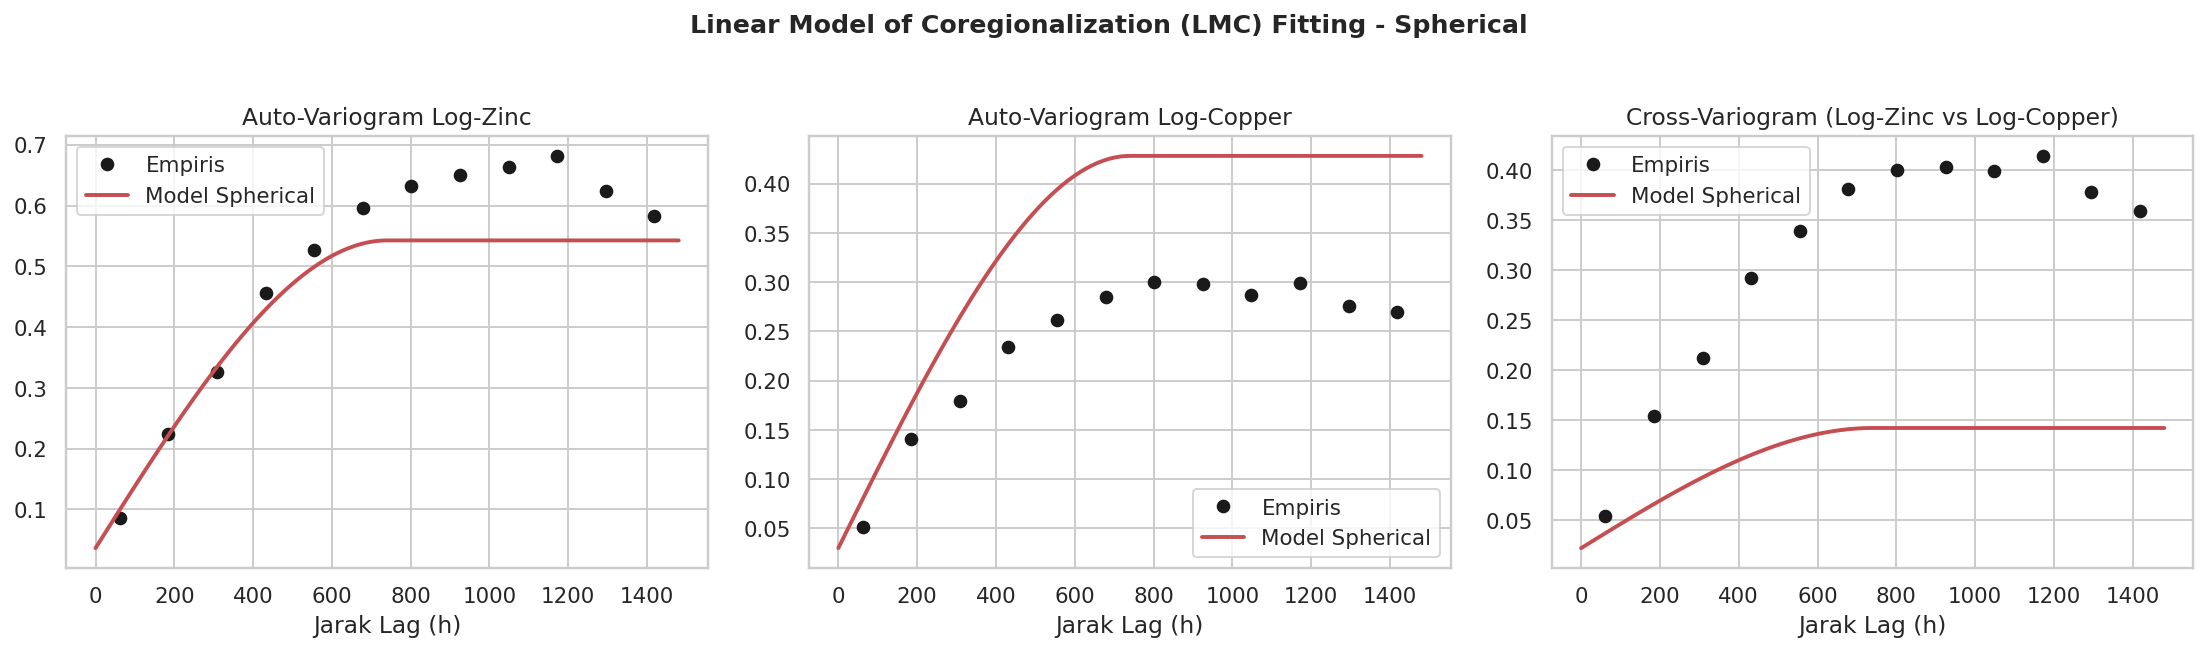


[INFO] Menjalankan Leave-One-Out Cross-Validation (LOOCV) Co-Kriging...

 HASIL EVALUASI VALIDASI SILANG ORDINARY CO-KRIGING
 RMSE (Skala Log) : 0.3907
 MAE (Skala Log)  : 0.2884
 Koefisien (R²)   : 0.7052

[INFO] Membangun Grid Peta Interpolasi dan Ragam Kriging...

Ringkasan Statistik Prediksi Skala Asli Zinc:
- Minimum  : 116.70
- Maksimum : 1851.00
- Rata-rata: 469.88

Ringkasan Statistik Ragam Kriging (Ketidakpastian):
- Rata-rata: 0.3446
- Minimum  : 0.0451
- Maksimum : 0.5681


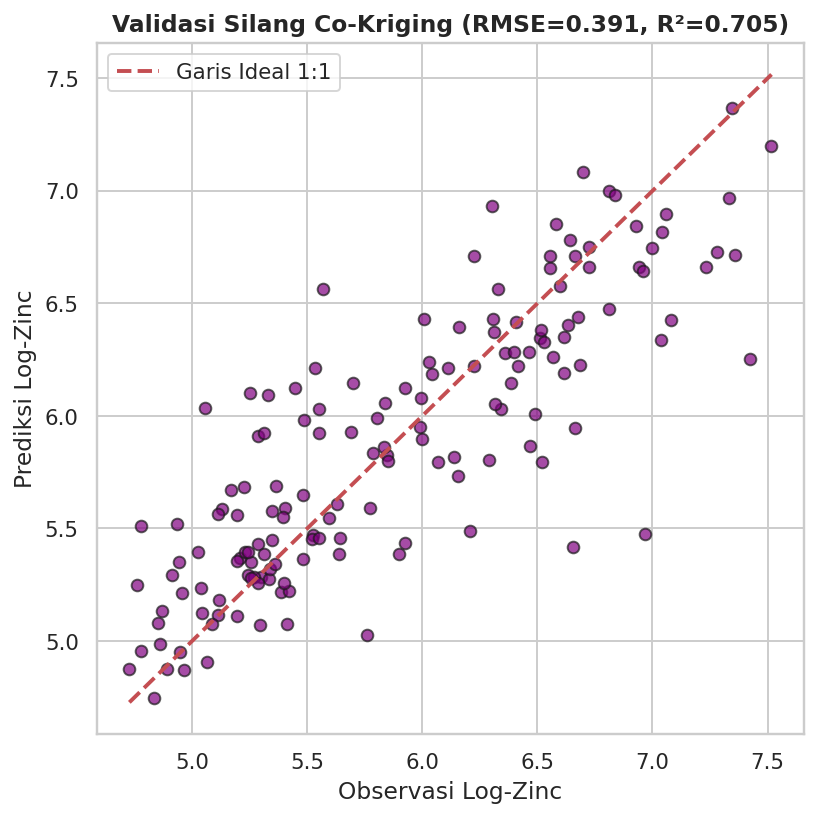

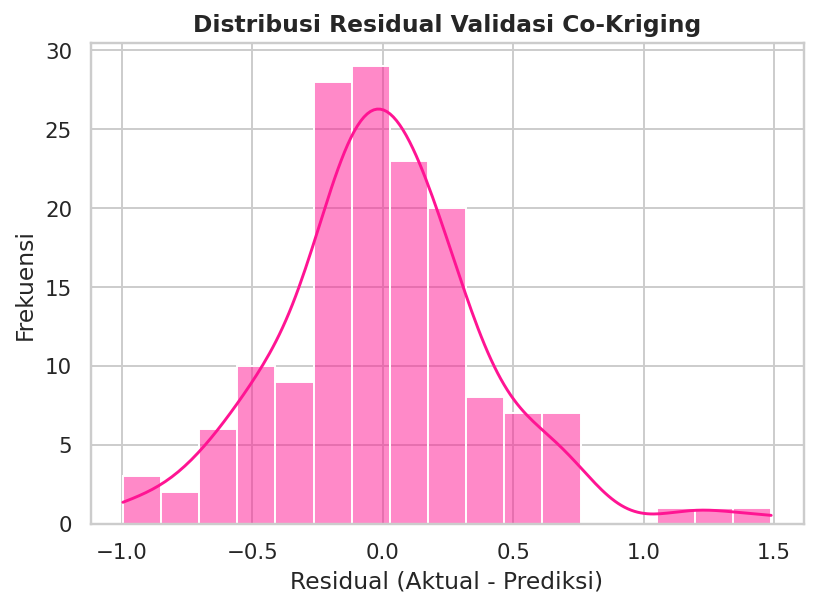

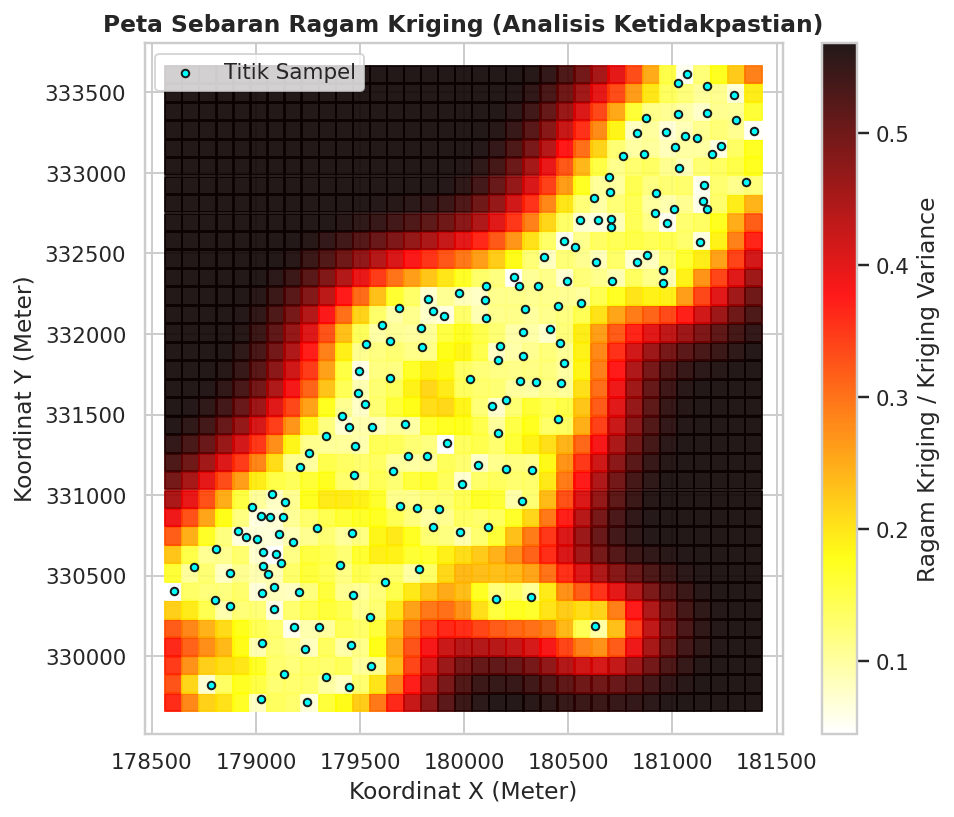

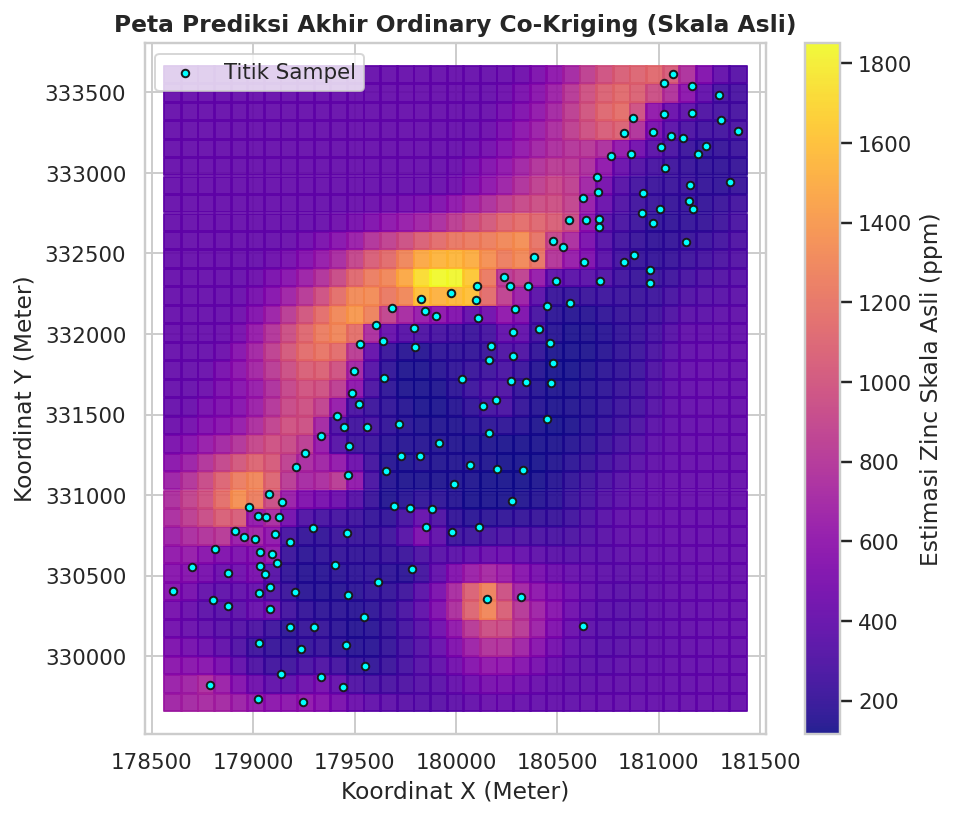

In [14]:
# ==============================================================================
# SCRIPT PYTHON FULL FINAL & KOMPREHENSIF: ORDINARY CO-KRIGING ANALISIS SPASIAL
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import minimize
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Pengaturan Tema Visualisasi Akademik
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 140

# ==============================================================================
# TAHAP 1: UPLOAD DATA, STATISTIK DESKRIPTIF, & ANALISIS KORELASI SILANG DETAIL
# ==============================================================================
print("Silakan pilih dan upload file 'meuse.txt' dari perangkat Anda:")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df_meuse = pd.read_csv(filename).dropna(subset=['zinc', 'copper', 'lead', 'cadmium'])

print(f"\n[INFO] Total data valid dimuat: {len(df_meuse)} baris observasi.")

# A. Statistik Deskriptif Awal (Sebelum Transformasi)
print("\n" + "="*70)
print(" 1. ANALISIS STATISTIK DESKRIPTIF VARIABEL UTAMA & SEKUNDER")
print("="*70)
desc_table = df_meuse[['zinc', 'copper', 'lead', 'cadmium']].describe().T[['count', 'mean', 'std', 'min', '50%', 'max']]
desc_table.columns = ['Count', 'Mean', "Std", 'Min', 'Median', 'Max']
print(desc_table.to_string())
print("="*70)

# B. Transformasi Logaritma Natural untuk Mengatasi Kemencengan (Skewness)
df_meuse['log_zinc'] = np.log(df_meuse['zinc'])
df_meuse['log_copper'] = np.log(df_meuse['copper'])

print("\n[INFO] Dilakukan transformasi Log-Natural pada Zinc (Primer) dan Copper (Sekunder)")
print(f"- Skewness Log-Zinc   : {stats.skew(df_meuse['log_zinc']):.4f}")
print(f"- Skewness Log-Copper : {stats.skew(df_meuse['log_copper']):.4f}")

# C. Analisis Korelasi Silang Pearson Komprehensif
corr_matrix = df_meuse[['log_zinc', 'log_copper', 'lead', 'cadmium']].corr()
r_val = corr_matrix.loc['log_zinc', 'log_copper']
p_val_corr = stats.pearsonr(df_meuse['log_zinc'], df_meuse['log_copper'])[1]

print("\n" + "="*70)
print(" 2. UJI KORELASI SILANG (PEARSON) ANTARA PEUBAH PRIMER & SEKUNDER")
print("="*70)
print(corr_matrix[['log_copper']])
print("-"*70)
print(f" Koefisien Korelasi (r) antara Log-Zinc & Log-Copper : {r_val:.4f}")
print(f" Nilai p-value uji signifikansi korelasi               : {p_val_corr:.4e}")

# Penentuan Kategori Kekuatan Korelasi secara Statistik Akademik
abs_r = abs(r_val)
if abs_r >= 0.8:
    strength = "Sangat Kuat (Validasi Co-Kriging Sangat Optimal)"
elif abs_r >= 0.6:
    strength = "Kuat (Validasi Co-Kriging Sangat Direkomendasikan)"
elif abs_r >= 0.4:
    strength = "Sedang (Korelasi Cukup untuk Membantu Estimasi)"
elif abs_r >= 0.2:
    strength = "Lemah (Pengaruh Variabel Sekunder Terbatas)"
else:
    strength = "Sangat Lemah / Tidak Signifikan"

print(f" Kesimpulan Kekuatan Hubungan Spasial          : {strength}")
print("="*70)


# ==============================================================================
# TAHAP 2: PERHITUNGAN VARIOGRAM EMPIRIS & CROSS-VARIOGRAM (LMC BUILD)
# ==============================================================================
coords = df_meuse[['x', 'y']].values
z1_log = df_meuse['log_zinc'].values       # Peubah Primer (Log-Zinc)
z2_log = df_meuse['log_copper'].values   # Peubah Sekunder (Log-Copper)

def compute_coregionalization_variograms(coords, z1, z2, n_lags=12, max_dist=None):
    dist_matrix = squareform(pdist(coords))
    if max_dist is None: max_dist = np.max(dist_matrix) / 3.0

    dz1, dz2 = z1[:, None] - z1[None, :], z2[:, None] - z2[None, :]
    g11_mat = 0.5 * (dz1**2)
    g22_mat = 0.5 * (dz2**2)
    g12_mat = 0.5 * (dz1 * dz2)

    bins = np.linspace(0, max_dist, n_lags + 1)
    lags = 0.5 * (bins[:-1] + bins[1:])
    g11, g22, g12 = [], [], []

    for i in range(n_lags):
        mask = (dist_matrix >= bins[i]) & (dist_matrix < bins[i+1])
        if np.sum(mask) > 0:
            g11.append(np.mean(g11_mat[mask]))
            g22.append(np.mean(g22_mat[mask]))
            g12.append(np.mean(g12_mat[mask]))
        else:
            g11.append(np.nan); g22.append(np.nan); g12.append(np.nan)

    return lags, np.array(g11), np.array(g22), np.array(g12)

max_d = np.max(pdist(coords)) / 3.0
lags, g11_emp, g22_emp, g12_emp = compute_coregionalization_variograms(coords, z1_log, z2_log, max_dist=max_d)


# ==============================================================================
# TAHAP 3: FITTING MODEL TEORETIS LMC & PEMILIHAN MODEL TERBAIK (SSE)
# ==============================================================================
def model_func(h, a, m_type):
    h = np.asarray(h)
    if m_type == 'spherical':
        return np.where(h <= a, 1.5 * (h / a) - 0.5 * (h / a)**3, 1.0)
    elif m_type == 'exponential':
        return 1.0 - np.exp(-h / a)
    elif m_type == 'gaussian':
        return 1.0 - np.exp(-(h**2) / (a**2))

def fit_lmc(m_type):
    def loss(params):
        c11_0, c22_0, c12_0, c11_1, c22_1, c12_1, a = params
        if (c12_0**2 > c11_0 * c22_0) or (c12_1**2 > c11_1 * c22_1) or (a <= 0): return 1e9

        g11_p = c11_0 + c11_1 * model_func(lags, a, m_type)
        g22_p = c22_0 + c22_1 * model_func(lags, a, m_type)
        g12_p = c12_0 + c12_1 * model_func(lags, a, m_type)

        valid = ~np.isnan(g11_emp)
        sse = np.sum((g11_emp[valid] - g11_p[valid])**2) + \
              np.sum((g22_emp[valid] - g22_p[valid])**2) + \
              np.sum((g12_emp[valid] - g12_p[valid])**2)
        return sse

    res = minimize(loss, [0.03, 0.03, 0.0, 0.5, 0.4, 0.1, max_d/2],
                   bounds=[(0,None),(0,None),(None,None),(0,None),(0,None),(None,None),(10,max_d)],
                   method='L-BFGS-B')
    return res.x, res.fun

p_exp, sse_exp = fit_lmc('exponential')
p_sph, sse_sph = fit_lmc('spherical')
p_gau, sse_gau = fit_lmc('gaussian')

# Tabel Perbandingan Parameter LMC
df_lacking_table = pd.DataFrame({
    'Model LMC': ['Exponential', 'Spherical', 'Gaussian'],
    'Nugget Primer (c0)': [p_exp[0], p_sph[0], p_gau[0]],
    'Sill Total Primer (c0+c)': [p_exp[0]+p_exp[3], p_sph[0]+p_sph[3], p_gau[0]+p_gau[3]],
    'Range (a)': [p_exp[6], p_sph[6], p_gau[6]],
    'Nilai SSE': [sse_exp, sse_sph, sse_gau]
})

print("\n" + "="*80)
print(" TABEL 3.1: PARAMETER HASIL FITTING MODEL VARIOGRAM LMC")
print("="*80)
print(df_lacking_table.to_string(index=False))
print("="*80)

best_model_name = df_lacking_table.loc[df_lacking_table['Nilai SSE'].idxmin(), 'Model LMC']
print(f"\n[INFO] Model LMC terbaik terpilih berdasarkan SSE terkecil: {best_model_name}")

if best_model_name == 'Exponential':
    c11_0, c22_0, c12_0, c11_1, c22_1, c12_1, range_lmc = p_exp
    m_type_sel = 'exponential'
elif best_model_name == 'Spherical':
    c11_0, c22_0, c12_0, c11_1, c22_1, c12_1, range_lmc = p_sph
    m_type_sel = 'spherical'
else:
    c11_0, c22_0, c12_0, c11_1, c22_1, c12_1, range_lmc = p_gau
    m_type_sel = 'gaussian'

# Visualisasi LMC Fitting
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
h_grid = np.linspace(0, max_d, 100)

for idx, (emp, title, c0, c1) in enumerate([
    (g11_emp, 'Auto-Variogram Log-Zinc', c11_0, c11_1),
    (g22_emp, 'Auto-Variogram Log-Copper', c22_0, c22_1),
    (g12_emp, 'Cross-Variogram (Log-Zinc vs Log-Copper)', c12_0, c12_1)
]):
    axes[idx].plot(lags, emp, 'ko', label='Empiris')
    axes[idx].plot(h_grid, c0 + c1 * model_func(h_grid, range_lmc, m_type_sel), 'r-', lw=2, label=f'Model {best_model_name}')
    axes[idx].set_title(title)
    axes[idx].set_xlabel('Jarak Lag (h)')
    axes[idx].legend()

plt.suptitle(f'Linear Model of Coregionalization (LMC) Fitting - {best_model_name}', fontsize=13, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()


# ==============================================================================
# TAHAP 4 & 5: ORDINARY CO-KRIGING, VALIDASI SILANG, & KETIDAKPASTIAN
# ==============================================================================
def get_cov(h, c0, c1, a, m_type):
    return (c0 + c1) - (c0 + c1 * model_func(h, a, m_type))

def ock_predict_single(s_coords, z1_s, z2_s, target_coord):
    n = len(s_coords)
    D = squareform(pdist(s_coords))
    C11 = get_cov(D, c11_0, c11_1, range_lmc, m_type_sel)
    C22 = get_cov(D, c22_0, c22_1, range_lmc, m_type_sel)
    C12 = get_cov(D, c12_0, c12_1, range_lmc, m_type_sel)

    K = np.zeros((2*n + 2, 2*n + 2))
    K[0:n, 0:n] = C11; K[0:n, n:2*n] = C12
    K[n:2*n, 0:n] = C12.T; K[n:2*n, n:2*n] = C22
    K[0:n, 2*n] = 1.0; K[2*n, 0:n] = 1.0
    K[n:2*n, 2*n+1] = 1.0; K[2*n+1, n:2*n] = 1.0

    dt = np.sqrt(np.sum((s_coords - target_coord)**2, axis=1))
    c11_t = get_cov(dt, c11_0, c11_1, range_lmc, m_type_sel)
    c12_t = get_cov(dt, c12_0, c12_1, range_lmc, m_type_sel)

    k0 = np.zeros(2*n + 2)
    k0[0:n] = c11_t; k0[n:2*n] = c12_t; k0[2*n] = 1.0; k0[2*n+1] = 0.0

    weights = np.linalg.solve(K + np.eye(2*n+2)*1e-5, k0)
    log_pred = np.sum(weights[0:n] * z1_s) + np.sum(weights[n:2*n] * z2_s)

    # Kriging Variance (Analisis Ketidakpastian)
    lagrange_mu1 = weights[2*n]
    variance = c11_0 + c11_1 - (np.sum(weights[0:n] * c11_t) + np.sum(weights[n:2*n] * c12_t) + lagrange_mu1)

    return np.exp(log_pred), log_pred, variance

print("\n[INFO] Menjalankan Leave-One-Out Cross-Validation (LOOCV) Co-Kriging...")
y_true_log = df_meuse['log_zinc'].values
y_pred_log, residuals = [], []

for i in range(len(coords)):
    mask = np.ones(len(coords), dtype=bool)
    mask[i] = False
    _, l_pred, _ = ock_predict_single(coords[mask], z1_log[mask], z2_log[mask], coords[i])
    y_pred_log.append(l_pred)
    residuals.append(y_true_log[i] - l_pred)

y_pred_log = np.array(y_pred_log)
residuals = np.array(residuals)

rmse = np.sqrt(mean_squared_error(y_true_log, y_pred_log))
mae = mean_absolute_error(y_true_log, y_pred_log)
r2 = r2_score(y_true_log, y_pred_log)

print("\n" + "="*55)
print(" HASIL EVALUASI VALIDASI SILANG ORDINARY CO-KRIGING")
print("="*55)
print(f" RMSE (Skala Log) : {rmse:.4f}")
print(f" MAE (Skala Log)  : {mae:.4f}")
print(f" Koefisien (R²)   : {r2:.4f}")
print("="*55)


# ==============================================================================
# TAHAP 6: PEMBUATAN PETA PREDIKSI SPASIAL & ANALISIS KETIDAKPASTIAN (GRID)
# ==============================================================================
print("\n[INFO] Membangun Grid Peta Interpolasi dan Ragam Kriging...")
grid_x = np.linspace(df_meuse['x'].min(), df_meuse['x'].max(), 35)
grid_y = np.linspace(df_meuse['y'].min(), df_meuse['y'].max(), 35)
GX, GY = np.meshgrid(grid_x, grid_y)
G_coords = np.c_[GX.ravel(), GY.ravel()]

preds_original, krig_vars = [], []
for pt in G_coords:
    p_orig, _, var = ock_predict_single(coords, z1_log, z2_log, pt)
    preds_original.append(p_orig)
    krig_vars.append(max(0, var))

preds_original = np.array(preds_original)
krig_vars = np.array(krig_vars)

print(f"\nRingkasan Statistik Prediksi Skala Asli Zinc:")
print(f"- Minimum  : {preds_original.min():.2f}")
print(f"- Maksimum : {preds_original.max():.2f}")
print(f"- Rata-rata: {preds_original.mean():.2f}")

print(f"\nRingkasan Statistik Ragam Kriging (Ketidakpastian):")
print(f"- Rata-rata: {krig_vars.mean():.4f}")
print(f"- Minimum  : {krig_vars.min():.4f}")
print(f"- Maksimum : {krig_vars.max():.4f}")

# Visualisasi 1: Scatter Plot Validasi Silang
plt.figure(figsize=(6, 6))
plt.scatter(y_true_log, y_pred_log, color='purple', alpha=0.7, edgecolors='k')
plt.plot([y_true_log.min(), y_true_log.max()], [y_true_log.min(), y_true_log.max()], 'r--', lw=2, label='Garis Ideal 1:1')
plt.title(f'Validasi Silang Co-Kriging (RMSE={rmse:.3f}, R²={r2:.3f})', fontsize=12, fontweight='bold')
plt.xlabel('Observasi Log-Zinc')
plt.ylabel('Prediksi Log-Zinc')
plt.legend()
plt.tight_layout()
plt.show()

# Visualisasi 2: Distribusi Residual
plt.figure(figsize=(6, 4.5))
sns.histplot(residuals, kde=True, color='deeppink')
plt.title('Distribusi Residual Validasi Co-Kriging', fontsize=12, fontweight='bold')
plt.xlabel('Residual (Aktual - Prediksi)')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

# Visualisasi 3: Peta Sebaran Ragam Kriging (Ketidakpastian)
plt.figure(figsize=(7, 6))
plt.scatter(G_coords[:, 0], G_coords[:, 1], c=krig_vars, cmap='hot_r', s=80, marker='s', alpha=0.9)
plt.colorbar(label='Ragam Kriging / Kriging Variance')
plt.scatter(df_meuse['x'], df_meuse['y'], c='cyan', s=15, edgecolors='k', label='Titik Sampel')
plt.title('Peta Sebaran Ragam Kriging (Analisis Ketidakpastian)', fontsize=12, fontweight='bold')
plt.xlabel('Koordinat X (Meter)')
plt.ylabel('Koordinat Y (Meter)')
plt.legend()
plt.tight_layout()
plt.show()

# Visualisasi 4: Peta Prediksi Akhir Co-Kriging Skala Asli
plt.figure(figsize=(7, 6))
plt.scatter(G_coords[:, 0], G_coords[:, 1], c=preds_original, cmap='plasma', s=80, marker='s', alpha=0.9)
plt.colorbar(label='Estimasi Zinc Skala Asli (ppm)')
plt.scatter(df_meuse['x'], df_meuse['y'], c='cyan', s=15, edgecolors='k', label='Titik Sampel')
plt.title('Peta Prediksi Akhir Ordinary Co-Kriging (Skala Asli)', fontsize=12, fontweight='bold')
plt.xlabel('Koordinat X (Meter)')
plt.ylabel('Koordinat Y (Meter)')
plt.legend()
plt.tight_layout()
plt.show()